Нестерова Е. В. ИУ5-63Б

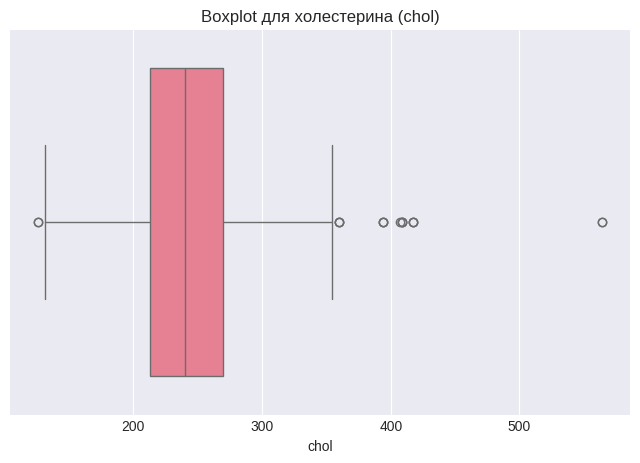

1. Обработка пропусков:
Для количественного признака chol использована замена пропусков на медиану, так как она устойчива к выбросам.
Для категориального признака thal использована замена на моду (наиболее частое значение).
2. Искусственное добавление пропусков:
Поскольку в исходном датасете пропуски отсутствовали, они были искусственно добавлены в размере 10% для признаков chol и thal.
3. Выбор признаков:
Для построения моделей используются признаки, имеющие медицинскую интерпретацию и потенциальную связь с заболеванием сердца.
Целевая переменная: target.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('heart.csv')
df.head()
df.isnull().sum()
# фиксируем random seed для воспроизводимости
np.random.seed(42)

# добавим 10% пропусков
missing_ratio = 0.1

# количественный признак
df.loc[df.sample(frac=missing_ratio).index, 'chol'] = np.nan

# категориальный признак
df.loc[df.sample(frac=missing_ratio).index, 'thal'] = np.nan

df.isnull().sum()
df['chol'] = df['chol'].fillna(df['chol'].median())
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])
features = [
    'age',
    'sex',
    'cp',        # chest pain
    'trestbps',  # давление
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal'
]

target = 'target'
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['chol'])
plt.title('Boxplot для холестерина (chol)')
plt.show()
print("""1. Обработка пропусков:
Для количественного признака chol использована замена пропусков на медиану, так как она устойчива к выбросам.
Для категориального признака thal использована замена на моду (наиболее частое значение).
2. Искусственное добавление пропусков:
Поскольку в исходном датасете пропуски отсутствовали, они были искусственно добавлены в размере 10% для признаков chol и thal.
3. Выбор признаков:
Для построения моделей используются признаки, имеющие медицинскую интерпретацию и потенциальную связь с заболеванием сердца.
Целевая переменная: target.""")
